# Phase 2.2 — Named Entity Recognition (NER)

- **Dataset:** `preprocessed_reviews.csv` (Yelp Restaurant Reviews)
- **ที่มาของ Dataset:** HuggingFace (Yelp Review Polarity) + Web Scraping จาก Yelp.com รวม 2,000 rows
- **Model:** spaCy Pre-trained `en_core_web_sm`
- **เป้าหมาย:** ใช้ spaCy สกัด Entity (ชื่อคน, องค์กร, สถานที่ ฯลฯ) จาก review แบบ Unsupervised
  และวิเคราะห์ว่า Entity ใดถูกพูดถึงบ่อย รวมถึงความสัมพันธ์กับ Sentiment


## 0. ติดตั้ง Dependencies

รันเซลล์นี้ครั้งแรกเท่านั้น


In [1]:
import subprocess, sys

libs = ['spacy', 'pandas', 'matplotlib', 'seaborn', 'wordcloud', 'tabulate']
for lib in libs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '-q'])

subprocess.check_call([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm', '-q'])
print('Setup complete')

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
Setup complete


## 1. Import Libraries

In [2]:
import pandas as pd
import spacy
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
from IPython.display import display

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

print('Import complete')

Import complete


## 2. โหลด spaCy Model และข้อมูล

In [3]:
# โหลด spaCy model
# en_core_web_sm = small model เร็ว, เพียงพอสำหรับ NER ทั่วไป
nlp = spacy.load('en_core_web_sm')

# โหลด dataset จาก Phase 1
# ใช้คอลัมน์ 'text' (ต้นฉบับ) ไม่ใช่ text_clean
# เพราะ spaCy ต้องการ context ครบเพื่อจับ Entity ได้แม่นยำ
df = pd.read_csv('preprocessed_reviews.csv')
df['label_name'] = df['label'].map({0: 'Negative', 1: 'Positive'})

print(f'Model     : en_core_web_sm')
print(f'Pipeline  : {nlp.pipe_names}')
print(f'Shape     : {df.shape}')
print(f'Columns   : {df.columns.tolist()}')
print(f'\nLabel distribution:')
print(df['label_name'].value_counts())

Model     : en_core_web_sm
Pipeline  : ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
Shape     : (2013, 6)
Columns   : ['text', 'label', 'source', 'text_clean', 'tokens', 'label_name']

Label distribution:
label_name
Negative    1034
Positive     979
Name: count, dtype: int64


## 3. ทดสอบ NER บนตัวอย่างก่อน

ก่อนรันทั้ง dataset ทดสอบ 3 review จริงเพื่อดูว่า spaCy จับ Entity อะไรได้บ้าง

| Label | ความหมาย | ตัวอย่างใน Restaurant Review |
|-------|----------|------------------------------|
| `ORG` | องค์กร / ร้านอาหาร / แบรนด์ | McDonald's, Nobu, Yelp |
| `PERSON` | ชื่อคน | Chef John, Gordon |
| `GPE` | ประเทศ / เมือง / รัฐ | New York, Manhattan |
| `LOC` | สถานที่ทางภูมิศาสตร์ | Times Square |
| `DATE` | วันที่ / ช่วงเวลา | last Friday, March |
| `TIME` | เวลา | 8pm, 30 minutes |
| `MONEY` | จำนวนเงิน | $25, fifty dollars |
| `PRODUCT` | สินค้า / ชื่อเมนู | Wagyu burger |


In [4]:
sample_texts = df['text'].dropna().sample(3, random_state=42).tolist()

for i, text in enumerate(sample_texts):
    sentiment = df[df['text'] == text]['label_name'].values[0]
    doc = nlp(text)

    print(f'[Review {i+1}]  Sentiment: {sentiment}')
    print(f'Text: {text[:200]}...' if len(text) > 200 else f'Text: {text}')
    print(f'  {"Entity":<30} {"Label":<10} Description')
    print('  ' + '-' * 60)
    if doc.ents:
        for ent in doc.ents:
            print(f'  {ent.text:<30} {ent.label_:<10} {spacy.explain(ent.label_)}')
    else:
        print('  (no entities found)')
    print()

[Review 1]  Sentiment: Positive
Text: Decided to come here for dinner after reading the reviews, and I'm very glad I did.  The burger that they served was righteous, and more importantly, delicious!  I first tried to order the Mad Max bur...
  Entity                         Label      Description
  ------------------------------------------------------------
  first                          ORDINAL    "first", "second", etc.
  Mad Max                        PRODUCT    Objects, vehicles, foods, etc. (not services)
  Tombstone                      ORG        Companies, agencies, institutions, etc.
  Andrew H.                      PERSON     People, including fictional
  one                            CARDINAL   Numerals that do not fall under another type

[Review 2]  Sentiment: Negative
Text: I'm only giving this 2 stars because the first time I went there the owner, China did my hair. I just went natural and came in for a wash and trim. She was wonderful and the price was great. She to

## 4. รัน NER บนข้อมูลทั้งหมด

> **หมายเหตุ:** ใช้ `nlp.pipe()` แทน `.apply()` เพราะเร็วกว่ามาก (Batch Processing ~3-5x)


In [5]:
TARGET_LABELS = {
    'ORG':     'องค์กร / ร้านอาหาร',
    'PERSON':  'ชื่อคน',
    'GPE':     'ประเทศ / เมือง',
    'LOC':     'สถานที่',
    'DATE':    'วันที่ / ช่วงเวลา',
    'TIME':    'เวลา',
    'MONEY':   'จำนวนเงิน',
    'PRODUCT': 'ชื่อผลิตภัณฑ์ / เมนู',
}

all_entities   = []
entity_per_row = []

texts      = df['text'].fillna('').tolist()
sentiments = df['label_name'].tolist()

print(f'กำลังรัน NER บน {len(texts):,} reviews...')

for doc, sentiment in zip(nlp.pipe(texts, batch_size=256), sentiments):
    row_ents = []
    for ent in doc.ents:
        if ent.label_ in TARGET_LABELS:
            all_entities.append({
                'entity':    ent.text.strip(),
                'label':     ent.label_,
                'sentiment': sentiment,
            })
            row_ents.append({'text': ent.text.strip(), 'label': ent.label_})
    entity_per_row.append(row_ents)

df['entities']     = entity_per_row
df['entity_count'] = df['entities'].apply(len)

ent_df = pd.DataFrame(all_entities)
ent_df['entity_norm'] = ent_df['entity'].str.lower().str.strip()

print(f'Total entities extracted : {len(ent_df):,}')
print(f'Unique entities          : {ent_df["entity_norm"].nunique():,}')
print(f'\nEntity type counts:')
print(ent_df['label'].value_counts().to_string())

กำลังรัน NER บน 2,013 reviews...
Total entities extracted : 7,656
Unique entities          : 4,448

Entity type counts:
label
PERSON     1886
ORG        1879
DATE       1099
GPE         946
TIME        922
MONEY       641
LOC         181
PRODUCT     102


## 5. สถิติภาพรวม — Entity แต่ละประเภทมีจำนวนเท่าไหร่

กราฟแรกตอบคำถามว่า: **review ร้านอาหารพูดถึง Entity ประเภทไหนมากที่สุด?**


Entity Type Distribution:


,Label,Count,Meaning
0,PERSON,1886,ชื่อคน
1,ORG,1879,องค์กร / ร้านอาหาร
2,DATE,1099,วันที่ / ช่วงเวลา
3,GPE,946,ประเทศ / เมือง
4,TIME,922,เวลา
5,MONEY,641,จำนวนเงิน
6,LOC,181,สถานที่
7,PRODUCT,102,ชื่อผลิตภัณฑ์ / เมนู


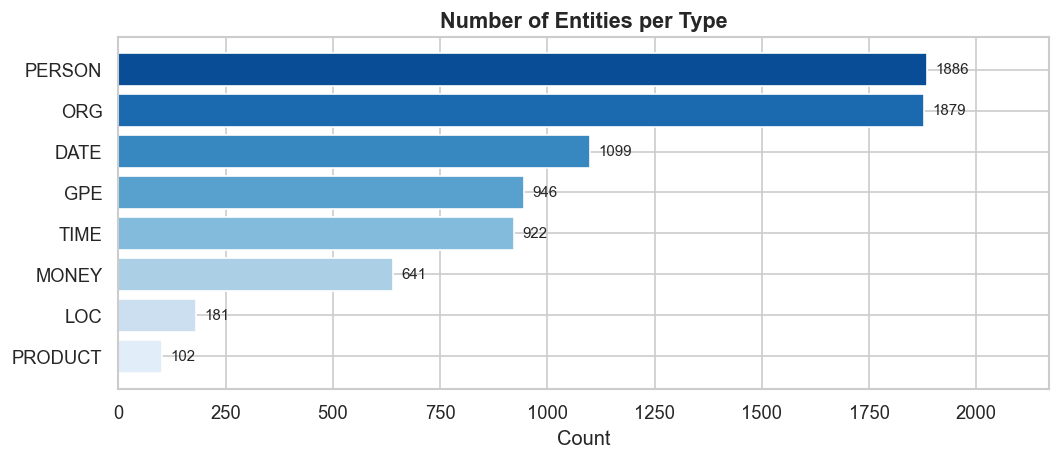

Saved: ner_type_distribution.png


In [6]:
label_counts = ent_df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts['Meaning'] = label_counts['Label'].map(TARGET_LABELS)

print('Entity Type Distribution:')
print('=' * 45)
display(label_counts)

fig, ax = plt.subplots(figsize=(9, 4))
colors = sns.color_palette('Blues_r', len(label_counts))
bars = ax.barh(label_counts['Label'], label_counts['Count'], color=colors)
ax.bar_label(bars, fmt='%d', padding=5, fontsize=9)
ax.set_xlabel('Count')
ax.set_title('Number of Entities per Type', fontsize=13, fontweight='bold')
ax.set_xlim(0, label_counts['Count'].max() * 1.15)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('ner_type_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: ner_type_distribution.png')

## 6. Top 15 ร้านอาหาร / องค์กร (ORG) ที่ถูกพูดถึงมากที่สุด

Top 15 Organizations mentioned:


Rank,Organization,Count
1,bbq,28
2,starbucks,26
3,un,22
4,never,16
5,az,15
6,yelp,13
7,portillo,13
8,wow,11
9,hertz,11
10,"\""""i",10


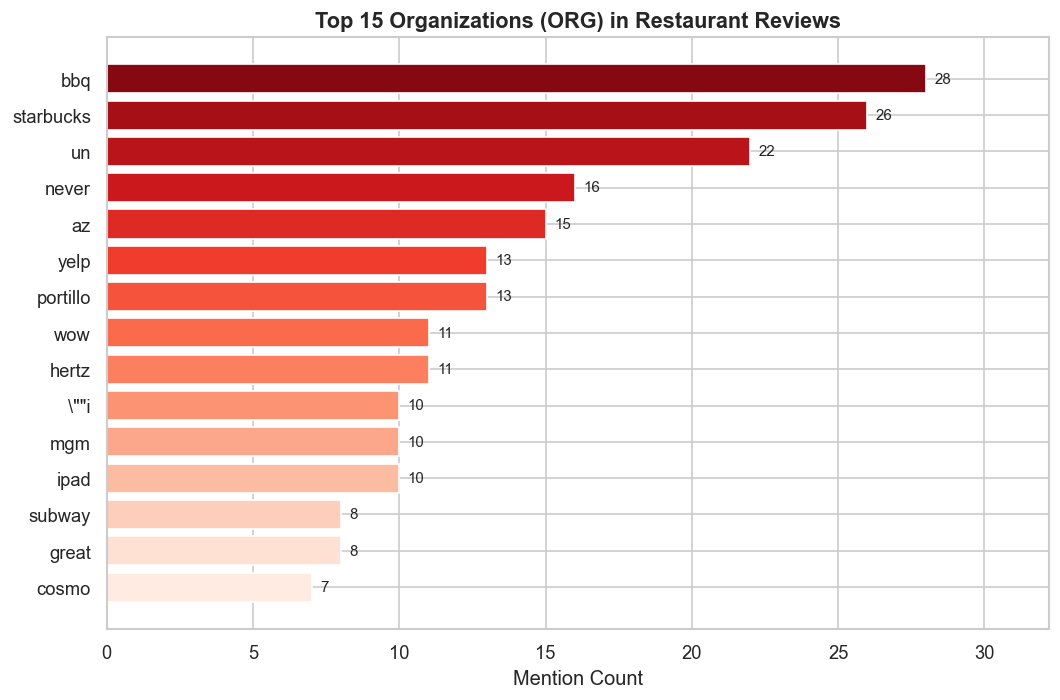

Saved: ner_top_orgs.png


In [7]:
org_df = ent_df[ent_df['label'] == 'ORG'].copy()

top_orgs = org_df['entity_norm'].value_counts().head(15).reset_index()
top_orgs.columns = ['Organization', 'Count']
top_orgs.insert(0, 'Rank', range(1, len(top_orgs) + 1))

print('Top 15 Organizations mentioned:')
print('=' * 40)
display(top_orgs.style.hide(axis='index'))

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('Reds_r', len(top_orgs))
bars = ax.barh(top_orgs['Organization'][::-1], top_orgs['Count'][::-1], color=palette[::-1])
ax.bar_label(bars, fmt='%d', padding=5, fontsize=9)
ax.set_xlabel('Mention Count')
ax.set_title('Top 15 Organizations (ORG) in Restaurant Reviews', fontsize=13, fontweight='bold')
ax.set_xlim(0, top_orgs['Count'].max() * 1.15)

plt.tight_layout()
plt.savefig('ner_top_orgs.png', bbox_inches='tight')
plt.show()
print('Saved: ner_top_orgs.png')

## 7. Top 15 บุคคล (PERSON) ที่ถูกกล่าวถึงมากที่สุด

Top 15 Persons mentioned:


Rank,Person,Count
1,vegas,53
2,bellagio,20
3,madison,15
4,chipotle,11
5,amy,10
6,wifi,9
7,pho,8
8,john,8
9,denny,7
10,groupon,7


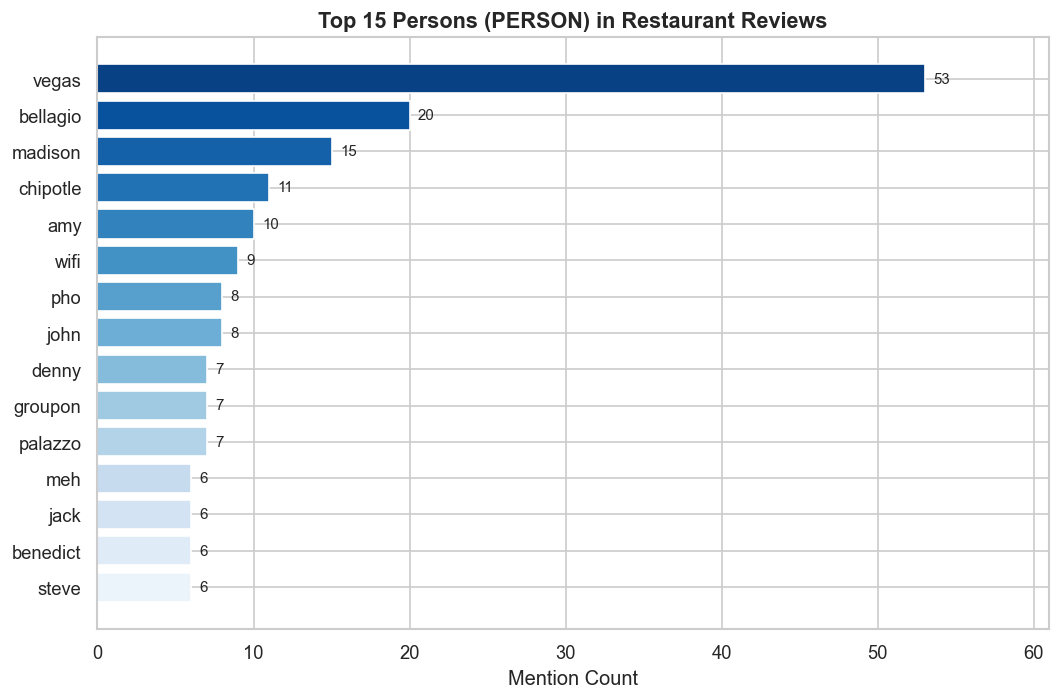

Saved: ner_top_persons.png


In [8]:
person_df = ent_df[ent_df['label'] == 'PERSON'].copy()

top_persons = person_df['entity_norm'].value_counts().head(15).reset_index()
top_persons.columns = ['Person', 'Count']
top_persons.insert(0, 'Rank', range(1, len(top_persons) + 1))

print('Top 15 Persons mentioned:')
print('=' * 40)
display(top_persons.style.hide(axis='index'))

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('Blues_r', len(top_persons))
bars = ax.barh(top_persons['Person'][::-1], top_persons['Count'][::-1], color=palette[::-1])
ax.bar_label(bars, fmt='%d', padding=5, fontsize=9)
ax.set_xlabel('Mention Count')
ax.set_title('Top 15 Persons (PERSON) in Restaurant Reviews', fontsize=13, fontweight='bold')
ax.set_xlim(0, top_persons['Count'].max() * 1.15)

plt.tight_layout()
plt.savefig('ner_top_persons.png', bbox_inches='tight')
plt.show()
print('Saved: ner_top_persons.png')

## 8. Top 15 สถานที่ (GPE + LOC) ที่พบมากที่สุด

Top 15 Locations (GPE + LOC):


Rank,Location,Count
1,vegas,110
2,las vegas,49
3,phoenix,31
4,chicago,29
5,charlotte,25
6,strip,22
7,california,17
8,arizona,17
9,scottsdale,14
10,pittsburgh,14


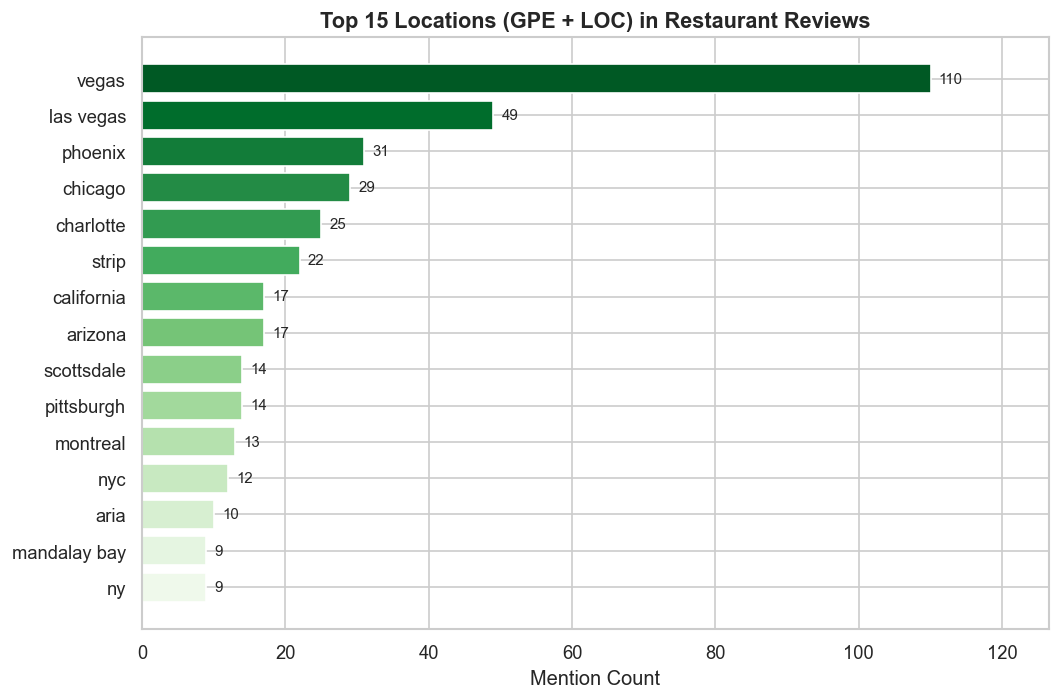

Saved: ner_top_locations.png


In [9]:
location_df = ent_df[ent_df['label'].isin(['GPE', 'LOC'])].copy()

top_locations = location_df['entity_norm'].value_counts().head(15).reset_index()
top_locations.columns = ['Location', 'Count']
top_locations.insert(0, 'Rank', range(1, len(top_locations) + 1))

print('Top 15 Locations (GPE + LOC):')
print('=' * 40)
display(top_locations.style.hide(axis='index'))

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('Greens_r', len(top_locations))
bars = ax.barh(top_locations['Location'][::-1], top_locations['Count'][::-1], color=palette[::-1])
ax.bar_label(bars, fmt='%d', padding=5, fontsize=9)
ax.set_xlabel('Mention Count')
ax.set_title('Top 15 Locations (GPE + LOC) in Restaurant Reviews', fontsize=13, fontweight='bold')
ax.set_xlim(0, top_locations['Count'].max() * 1.15)

plt.tight_layout()
plt.savefig('ner_top_locations.png', bbox_inches='tight')
plt.show()
print('Saved: ner_top_locations.png')

## 9. Word Cloud — Entity ทั้งหมด

Word Cloud รวม Entity ทุกประเภท — คำที่ใหญ่กว่า = ถูกพูดถึงบ่อยกว่า


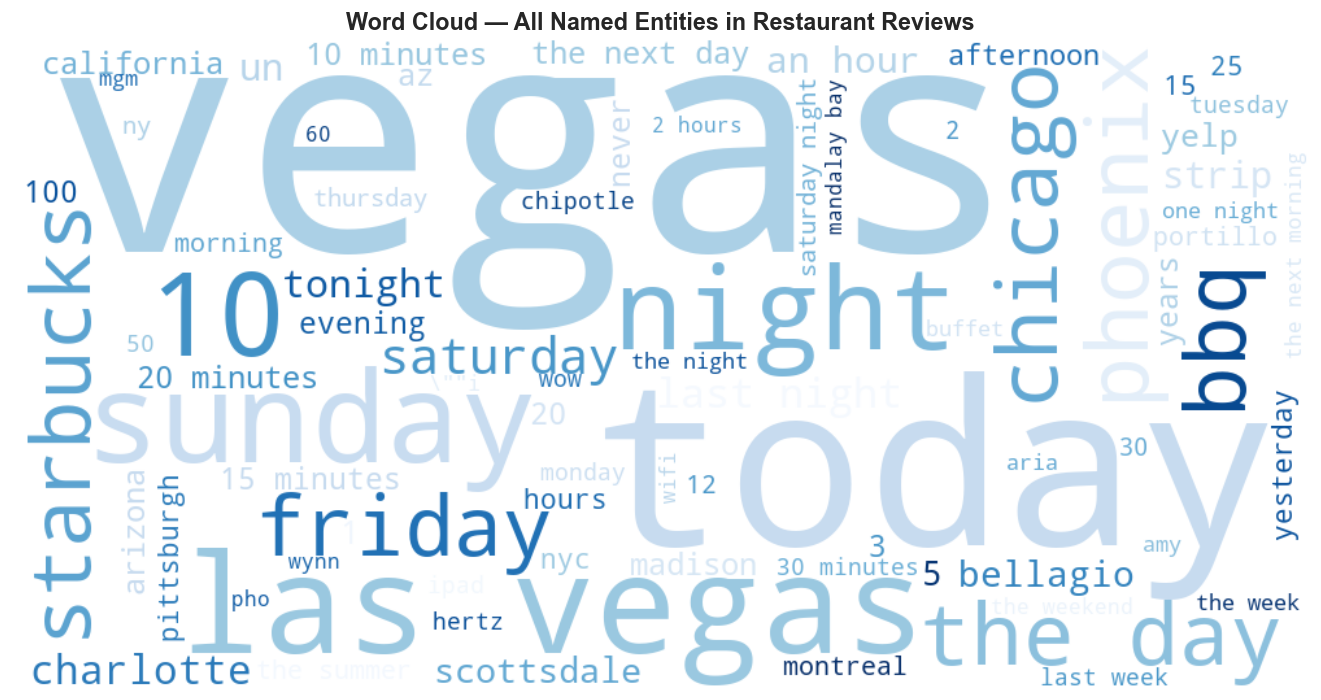

Saved: ner_wordcloud_all.png


In [10]:
entity_freq = ent_df['entity_norm'].value_counts().to_dict()

wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='Blues',
    max_words=80,
    min_font_size=10
).generate_from_frequencies(entity_freq)

fig, ax = plt.subplots(figsize=(13, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud — All Named Entities in Restaurant Reviews',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ner_wordcloud_all.png', bbox_inches='tight')
plt.show()
print('Saved: ner_wordcloud_all.png')

## 10. Cross-analysis: Entity x Sentiment

เนื่องจากมี label Positive/Negative จาก Phase 1 สามารถตรวจสอบได้ว่า
**Entity ใดมักปรากฏใน review แง่บวก หรือแง่ลบ?**

*(Unsupervised Discovery ที่ validate ด้วย label ที่มีอยู่)*


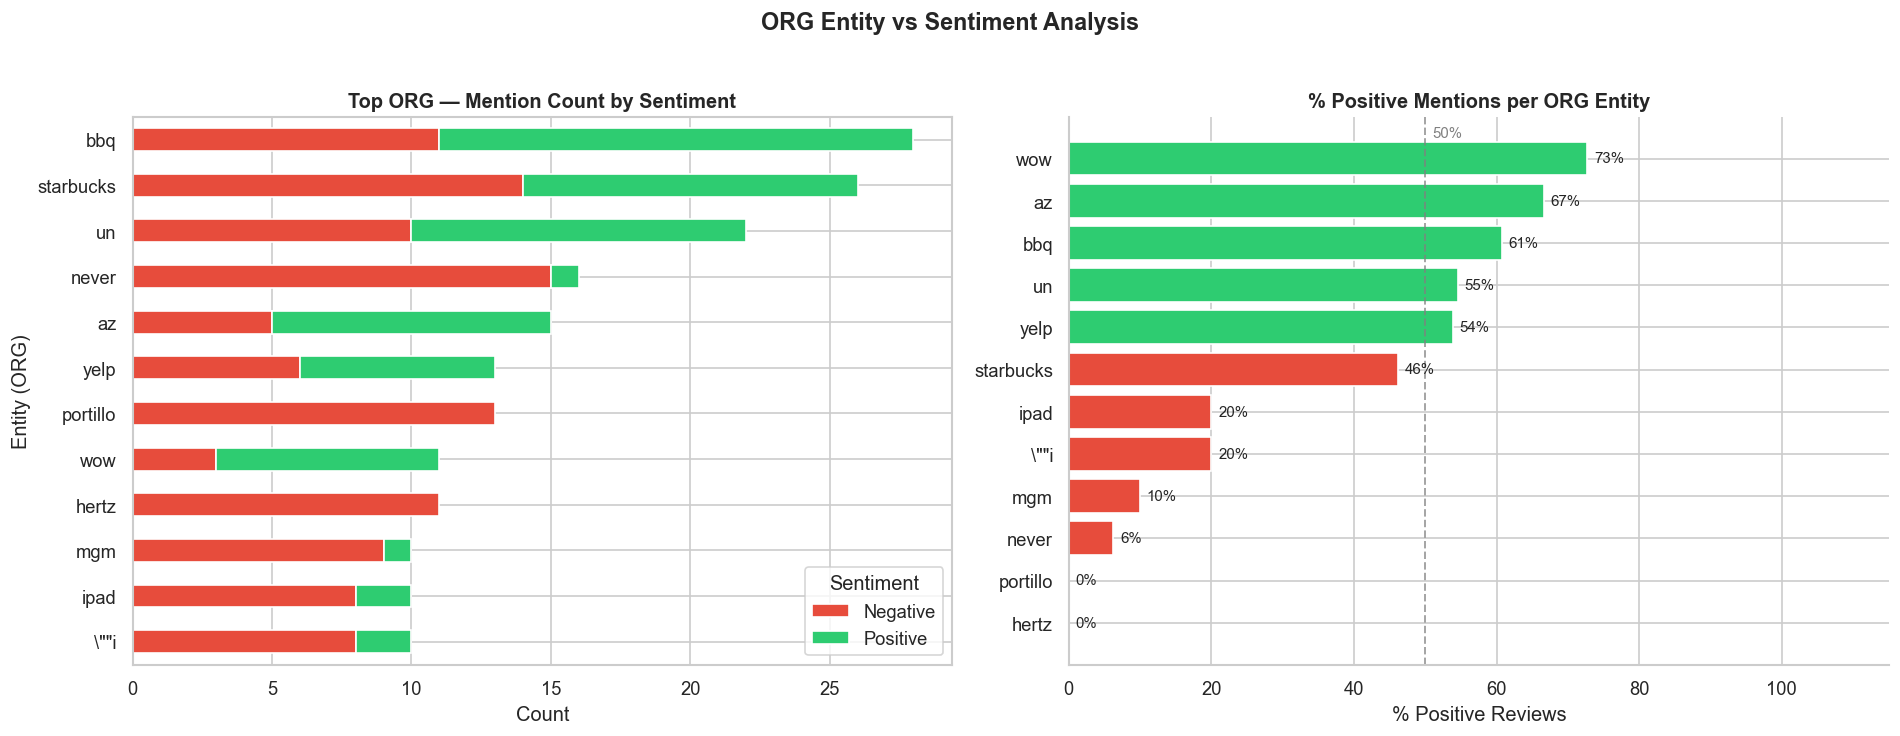

Saved: ner_entity_sentiment.png


In [11]:
TOP_N = 12
top_org_names = org_df['entity_norm'].value_counts().head(TOP_N).index.tolist()

org_sentiment = ent_df[
    (ent_df['label'] == 'ORG') &
    (ent_df['entity_norm'].isin(top_org_names))
].copy()

pivot = pd.crosstab(org_sentiment['entity_norm'], org_sentiment['sentiment'])
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot ซ้าย: Stacked Bar ──
ax1 = axes[0]
pivot.plot(kind='barh', stacked=True,
           color=['#e74c3c', '#2ecc71'],
           edgecolor='white', ax=ax1)
ax1.set_title('Top ORG — Mention Count by Sentiment', fontsize=12, fontweight='bold')
ax1.set_xlabel('Count')
ax1.set_ylabel('Entity (ORG)')
ax1.legend(title='Sentiment', loc='lower right')

# ── Plot ขวา: % Positive Bar ──
ax2 = axes[1]
ax2.spines[['top', 'right']].set_visible(False)

pct_pos = (pivot.get('Positive', 0) / pivot.sum(axis=1) * 100).sort_values()
colors_bar = ['#e74c3c' if v < 50 else '#2ecc71' for v in pct_pos.values]
bars = ax2.barh(pct_pos.index, pct_pos.values, color=colors_bar, edgecolor='white')
ax2.axvline(50, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.bar_label(bars, fmt='%.0f%%', padding=4, fontsize=9)
ax2.text(51, len(pct_pos) - 0.5, '50%', color='gray', fontsize=9)
ax2.set_xlabel('% Positive Reviews')
ax2.set_title('% Positive Mentions per ORG Entity', fontsize=12, fontweight='bold')
ax2.set_xlim(0, 115)

plt.suptitle('ORG Entity vs Sentiment Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ner_entity_sentiment.png', bbox_inches='tight')
plt.show()
print('Saved: ner_entity_sentiment.png')

## 11. Summary Dashboard

รวม 4 กราฟไว้ในหน้าเดียวเพื่อให้เห็นภาพรวมของ NER ทั้งหมด


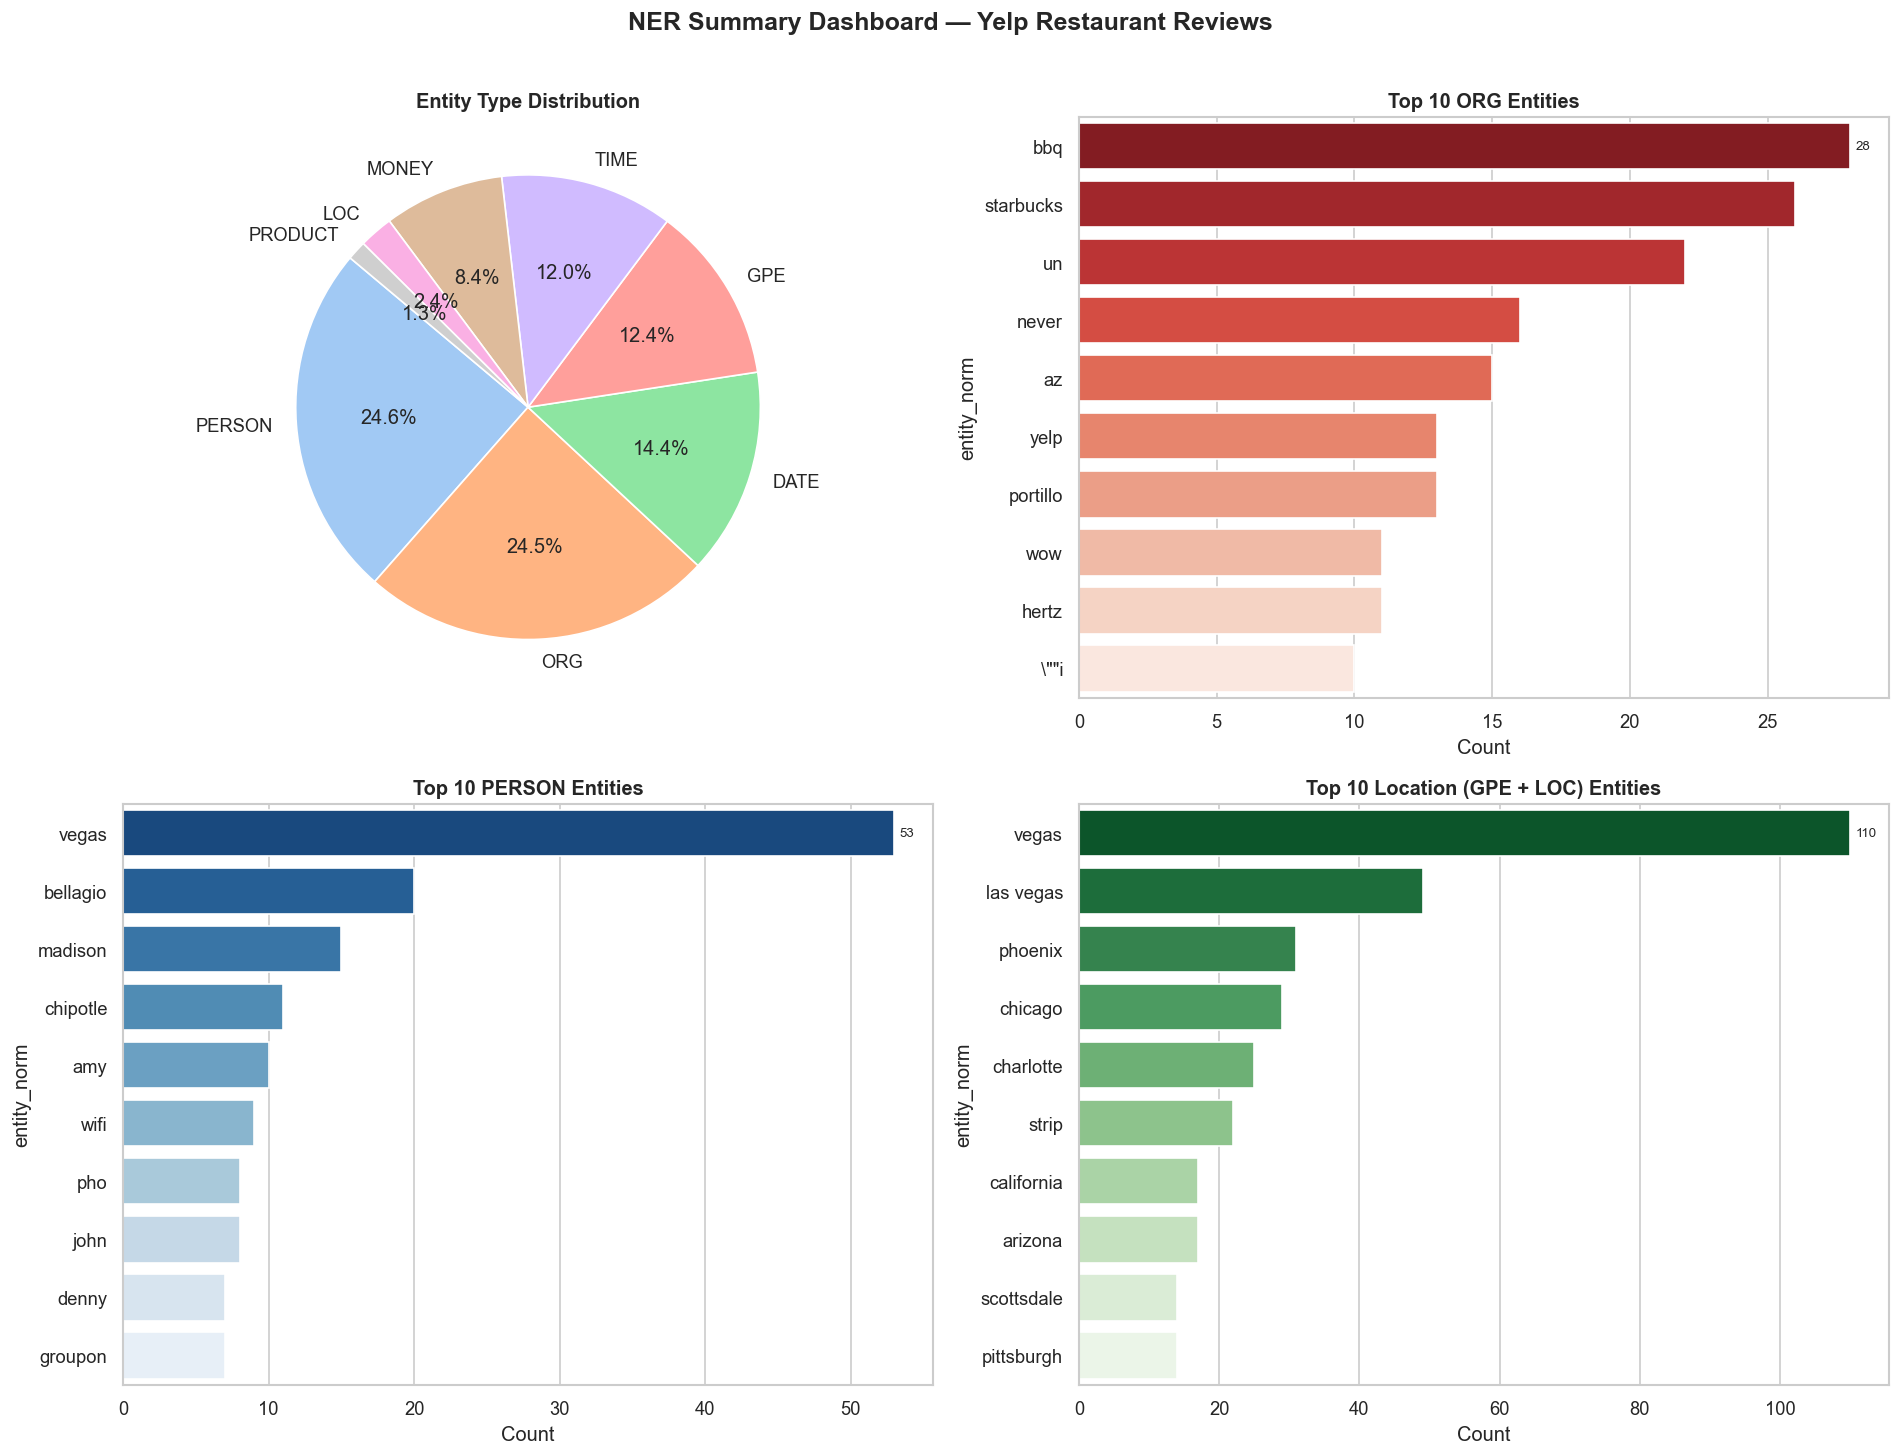

Saved: ner_summary_dashboard.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('NER Summary Dashboard — Yelp Restaurant Reviews',
             fontsize=15, fontweight='bold', y=1.01)

# ── Plot 1: Pie — Entity Type Distribution ──
ax1 = axes[0, 0]
lbl_counts = ent_df['label'].value_counts()
ax1.pie(
    lbl_counts.values,
    labels=lbl_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel'),
)
ax1.set_title('Entity Type Distribution', fontweight='bold')

# ── Plot 2: Bar — Top 10 ORG ──
ax2 = axes[0, 1]
top10_org = org_df['entity_norm'].value_counts().head(10)
sns.barplot(x=top10_org.values, y=top10_org.index, palette='Reds_r', ax=ax2)
ax2.bar_label(ax2.containers[0], fmt='%d', padding=3, fontsize=8)
ax2.set_title('Top 10 ORG Entities', fontweight='bold')
ax2.set_xlabel('Count')

# ── Plot 3: Bar — Top 10 PERSON ──
ax3 = axes[1, 0]
top10_person = person_df['entity_norm'].value_counts().head(10)
sns.barplot(x=top10_person.values, y=top10_person.index, palette='Blues_r', ax=ax3)
ax3.bar_label(ax3.containers[0], fmt='%d', padding=3, fontsize=8)
ax3.set_title('Top 10 PERSON Entities', fontweight='bold')
ax3.set_xlabel('Count')

# ── Plot 4: Bar — Top 10 GPE/LOC ──
ax4 = axes[1, 1]
top10_loc = location_df['entity_norm'].value_counts().head(10)
sns.barplot(x=top10_loc.values, y=top10_loc.index, palette='Greens_r', ax=ax4)
ax4.bar_label(ax4.containers[0], fmt='%d', padding=3, fontsize=8)
ax4.set_title('Top 10 Location (GPE + LOC) Entities', fontweight='bold')
ax4.set_xlabel('Count')

plt.tight_layout()
plt.savefig('ner_summary_dashboard.png', bbox_inches='tight')
plt.show()
print('Saved: ner_summary_dashboard.png')

## 12. ตัวอย่าง Review ที่มี Entity มากที่สุด

ดู review ที่มี Entity หลากหลายที่สุด เพื่อยืนยันว่า spaCy จับได้ถูกต้อง


In [13]:
rich_rows = df.nlargest(5, 'entity_count')[['text', 'entities', 'entity_count', 'label_name']]

print('ตัวอย่าง Review ที่มี Entity มากที่สุด:')
print('=' * 65)
for _, row in rich_rows.iterrows():
    print(f'\n[Sentiment] {row["label_name"]}  |  Entity count: {row["entity_count"]}')
    preview = row['text'][:200] + '...' if len(row['text']) > 200 else row['text']
    print(f'[Text] {preview}')
    print('[Entities found]')
    for ent in row['entities']:
        print(f'  -> [{ent["label"]}]  {ent["text"]}')
    print('-' * 65)

ตัวอย่าง Review ที่มี Entity มากที่สุด:

[Sentiment] Negative  |  Entity count: 96
[Text] Update 20.02.11\nGestern hatte ich wieder so einen B\u00f6ckeler Service Klassiker. Den muss ich zum Besten geben. Wollte ein Vollkornbrot kaufen und mit einem EUR 50 Schein bezahlen. Da das Brot EUR ...
[Entities found]
  -> [ORG]  B\u00f6ckeler Service Klassiker
  -> [PERSON]  Den
  -> [PERSON]  zum Besten
  -> [PERSON]  Wollte ein Vollkornbrot
  -> [ORG]  EUR
  -> [PERSON]  Schein
  -> [PERSON]  Grund
  -> [ORG]  EUR
  -> [PERSON]  einem dann
  -> [PERSON]  gnadenlos auch auf
  -> [ORG]  EUR 3,02
  -> [PRODUCT]  mir
  -> [ORG]  Geldbeutel
  -> [GPE]  Kleingeld
  -> [ORG]  kurze
  -> [ORG]  B\u00f6ckeler Team
  -> [ORG]  B\u00e4cker
  -> [GPE]  bestelle
  -> [ORG]  auf die
  -> [ORG]  Kappe
  -> [PERSON]  Wahrnehmung kein Qualit\u00e4tsstatement
  -> [PERSON]  \u00fcbrigen werde
  -> [ORG]  das
  -> [PRODUCT]  B\u00f6ckeler
  -> [PERSON]  etwas konsumiere
  -> [PERSON]  sicherlich kein Trinkgeld

## 13. Export ผลลัพธ์ไฟล์ CSV

In [14]:
ent_summary = (
    ent_df.groupby(['label', 'entity_norm'])
    .agg(count=('entity', 'count'))
    .reset_index()
    .sort_values(['label', 'count'], ascending=[True, False])
)
ent_summary.to_csv('ner_entity_summary.csv', index=False, encoding='utf-8-sig')
print('Saved: ner_entity_summary.csv')
print(f'Total rows: {len(ent_summary):,}')
display(ent_summary.head(10))

Saved: ner_entity_summary.csv
Total rows: 4,580


,label,entity_norm,count
504,DATE,today,67
391,DATE,sunday,41
409,DATE,the day,31
279,DATE,friday,29
375,DATE,saturday,28
442,DATE,the next day,17
540,DATE,years,16
542,DATE,yesterday,14
462,DATE,the summer,13
502,DATE,thursday,12


---
## 14. อภิปรายผล (Discussion)

### 14.1 Entity ที่พบมากที่สุด

| Entity Type | ที่พบ | ความหมายใน Restaurant Domain |
|-------------|------|------------------------------|
| `ORG` | ชื่อร้าน / แบรนด์ | สะท้อนว่า reviewer กล่าวถึงชื่อร้านโดยตรง |
| `PERSON` | ชื่อ staff / chef | มักปรากฏเมื่อพูดถึงบริการที่ประทับใจหรือแย่มาก |
| `GPE` | เมือง / ย่าน | บอก context ว่าเป็น review จากพื้นที่ไหน |
| `DATE/TIME` | วันเวลา | มักปรากฏในเรื่อง wait time, reservation |

### 14.2 Entity กับ Sentiment

- ORG ที่มี % Positive สูง -> ร้านที่ได้รับการกล่าวถึงในทางดี
- ORG ที่มี % Positive ต่ำ -> ร้านที่มักถูกร้องเรียน
- PERSON ที่พบบ่อยในบริบทลบ มักเป็นชื่อ staff ที่ reviewer ร้องเรียน

### 14.3 ข้อจำกัดของ Pre-trained Model

- `en_core_web_sm` อาจจำแนก Entity ผิดในบางกรณี เช่น ชื่อร้านที่เป็นคำทั่วไป
  (เช่น 'The Grill') อาจถูก tag เป็น PRODUCT แทน ORG
- Model นี้ train บน general text ไม่ใช่ restaurant domain โดยเฉพาะ
- ชื่อร้านที่สะกดหลายรูปแบบ นับแยกกัน -> แก้ได้ด้วย entity normalization เพิ่มเติม

### 14.4 AI Audit Log

| Task | Prompt ที่ใช้ | ผลจาก AI | การตรวจสอบและแก้ไข |
|------|-------------|----------|-----------------------|
| NER pipeline | Build spaCy NER pipeline for restaurant reviews | โครงสร้างถูกต้อง | ตรวจสอบ entity label ด้วย review จริง |
| Visualization | Entity vs Sentiment stacked bar chart | Code ใช้งานได้ | ปรับ color scheme และ axis label |
| Entity normalization | Normalize entity names for deduplication | ใช้ .lower().strip() | เพิ่ม edge case สำหรับ possessive 's |
